# Day 19: PCA for Feature Compression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
import time

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

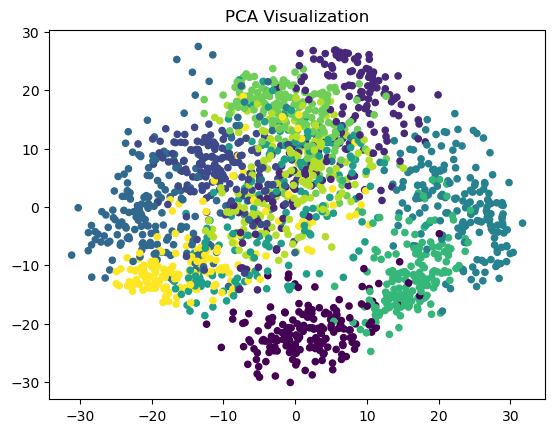

In [3]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y, cmap='viridis', s=20)
plt.title("PCA Visualization")
plt.show()

In [4]:
pca_full = PCA().fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = np.where(cum_var >= 0.95)[0][0] + 1
print("Components for 95%:", n_95)

Components for 95%: 29


In [5]:
# Without PCA
start = time.time()
model1 = LogisticRegression(max_iter=1000)
model1.fit(X, y)
time1 = time.time() - start

# With PCA
pca_95 = PCA(n_components=n_95)
X_pca = pca_95.fit_transform(X)

start = time.time()
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_pca, y)
time2 = time.time() - start

print("Without PCA:", time1)
print("With PCA:", time2)

Without PCA: 0.2586250305175781
With PCA: 0.14935612678527832


### Reflection

In MeetMux, having hundreds of features (like interests) makes computation slow.
PCA reduces the number of features while keeping important information.
This makes clustering faster and improves performance for real-time recommendations.